# EDA — Adult Census Income

**Задача:** бинарная классификация уровня годового дохода жителей США (`<=50K` / `>50K`)  
**Датасет:** [Adult Census Income, UCI / Kaggle](https://www.kaggle.com/datasets/uciml/adult-census-income)

In [46]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

SEED = 42
DATA_PATH = "../data/raw/adult.csv"
PROCESSED_PATH = "../data/processed/adult_processed.csv"

plt.rcParams["figure.dpi"] = 120

## 1. Источник и описание данных

Датасет получен из [репозитория UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/adult) и опубликован на Kaggle. Данные — результаты переписи населения США 1994 года.

**Почему выбран:** классический табличный бенчмарк для бинарной классификации с дисбалансом классов, широким набором категориальных и числовых признаков. Позволяет проверить полный ML-пайплайн от очистки до деплоя.

In [47]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


**Описание признаков:**

| Признак | Тип | Описание |
|---|---|---|
| `age` | числовой | Возраст |
| `workclass` | категориальный | Тип занятости (Private, Self-emp, Gov, ...) |
| `fnlwgt` | числовой | Вес наблюдения (демографический коэффициент) |
| `education` | категориальный | Уровень образования |
| `education.num` | числовой | Образование в числовой кодировке |
| `marital.status` | категориальный | Семейное положение |
| `occupation` | категориальный | Род деятельности |
| `relationship` | категориальный | Роль в семье |
| `race` | категориальный | Раса |
| `sex` | категориальный | Пол |
| `capital.gain` | числовой | Прирост капитала |
| `capital.loss` | числовой | Потери капитала |
| `hours.per.week` | числовой | Часов работы в неделю |
| `native.country` | категориальный | Страна рождения |
| `income` | **таргет** | Доход: `<=50K` или `>50K` |

## 2. Очистка данных

### 2.1 Пропущенные значения

В датасете пропуски закодированы символом `?`. Заменим их на `NaN`.

In [49]:
df = df.replace("?", np.nan)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"count": missing, "pct_%": missing_pct})

,count,pct_%
occupation,1843,5.66
workclass,1836,5.64
native.country,583,1.79


In [50]:
# Заполняем модой — пропусков немного (~6%), распределение не исказится
for col in ["workclass", "occupation", "native.country"]:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Пропусков после заполнения:", df.isnull().sum().sum())

Пропусков после заполнения: 0


### 2.2 Дубликаты

In [51]:
n_dups = df.duplicated().sum()
print(f"Дубликатов: {n_dups}")
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(f"Shape после удаления дублей: {df.shape}")

Дубликатов: 24
Shape после удаления дублей: (32537, 15)


### 2.3 Типы данных

In [52]:
CAT_COLS = [
    "workclass", "education", "marital.status",
    "occupation", "relationship", "race", "sex", "native.country",
]
NUM_COLS = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
TARGET = "income"

for col in CAT_COLS:
    df[col] = df[col].astype("category")

# Бинаризуем таргет: 1 = >50K, 0 = <=50K
df[TARGET] = (df[TARGET].str.strip() == ">50K").astype(int)

df.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education.num        int64
marital.status    category
occupation        category
relationship      category
race              category
sex               category
capital.gain         int64
capital.loss         int64
hours.per.week       int64
native.country    category
income               int64
dtype: object

### 2.4 Выбросы

`capital.gain` и `capital.loss` имеют тяжёлые правые хвосты: большинство значений равны нулю, а небольшое число наблюдений содержит очень большие суммы. Это экономически осмысленные значения (реальные транзакции), поэтому удалять их не будем, но зафиксируем.

In [53]:
df[NUM_COLS].describe().T.style.background_gradient(cmap="Blues", axis=1)

,count,mean,std,min,25%,50%,75%,max
age,32537.000000,38.585549,13.637984,17.000000,28.000000,37.000000,48.000000,90.000000
fnlwgt,32537.000000,189780.848511,105556.471009,12285.000000,117827.000000,178356.000000,236993.000000,1484705.000000
education.num,32537.000000,10.081815,2.571633,1.000000,9.000000,10.000000,12.000000,16.000000
capital.gain,32537.000000,1078.443741,7387.957424,0.000000,0.000000,0.000000,0.000000,99999.000000
capital.loss,32537.000000,87.368227,403.101833,0.000000,0.000000,0.000000,0.000000,4356.000000
hours.per.week,32537.000000,40.440329,12.346889,1.000000,40.000000,40.000000,45.000000,99.000000


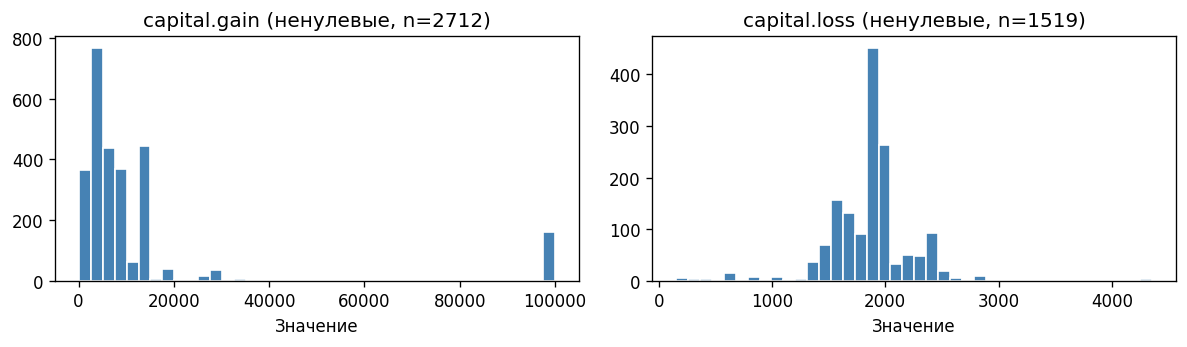

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, col in zip(axes, ["capital.gain", "capital.loss"]):
    nonzero = df[col][df[col] > 0]
    ax.hist(nonzero, bins=40, color="steelblue", edgecolor="white")
    ax.set_title(f"{col} (ненулевые, n={len(nonzero)})")
    ax.set_xlabel("Значение")
plt.tight_layout()
plt.show()

## 3. Визуализации

### 3.1 Распределение таргета

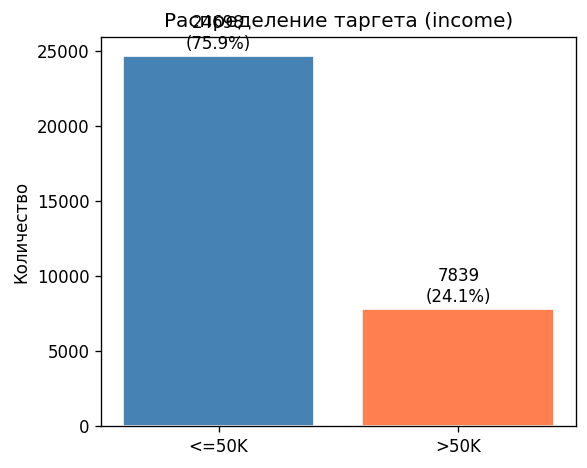

Дисбаланс классов: 3.15:1


In [55]:
counts = df[TARGET].value_counts()
labels = ["<=50K", ">50K"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, counts.values, color=["steelblue", "coral"], edgecolor="white")
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 200, f"{v}\n({v/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Распределение таргета (income)")
ax.set_ylabel("Количество")
plt.tight_layout()
plt.show()

print(f"Дисбаланс классов: {counts[0]/counts[1]:.2f}:1")

### 3.2 Числовые признаки

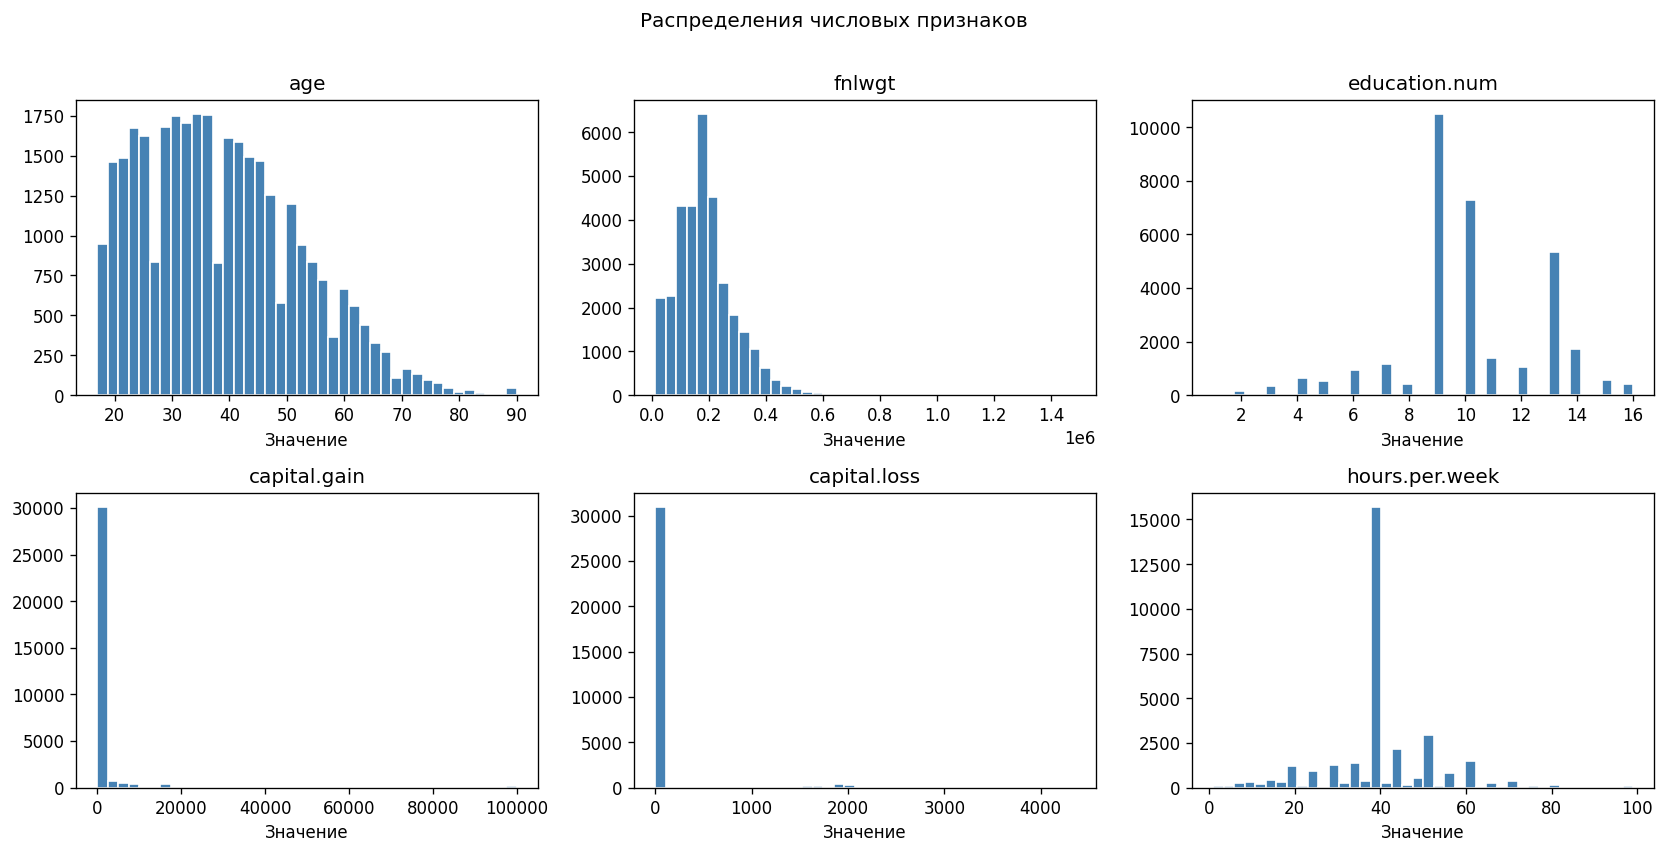

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, NUM_COLS):
    ax.hist(df[col], bins=40, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Значение")
plt.suptitle("Распределения числовых признаков", y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Числовые признаки vs таргет

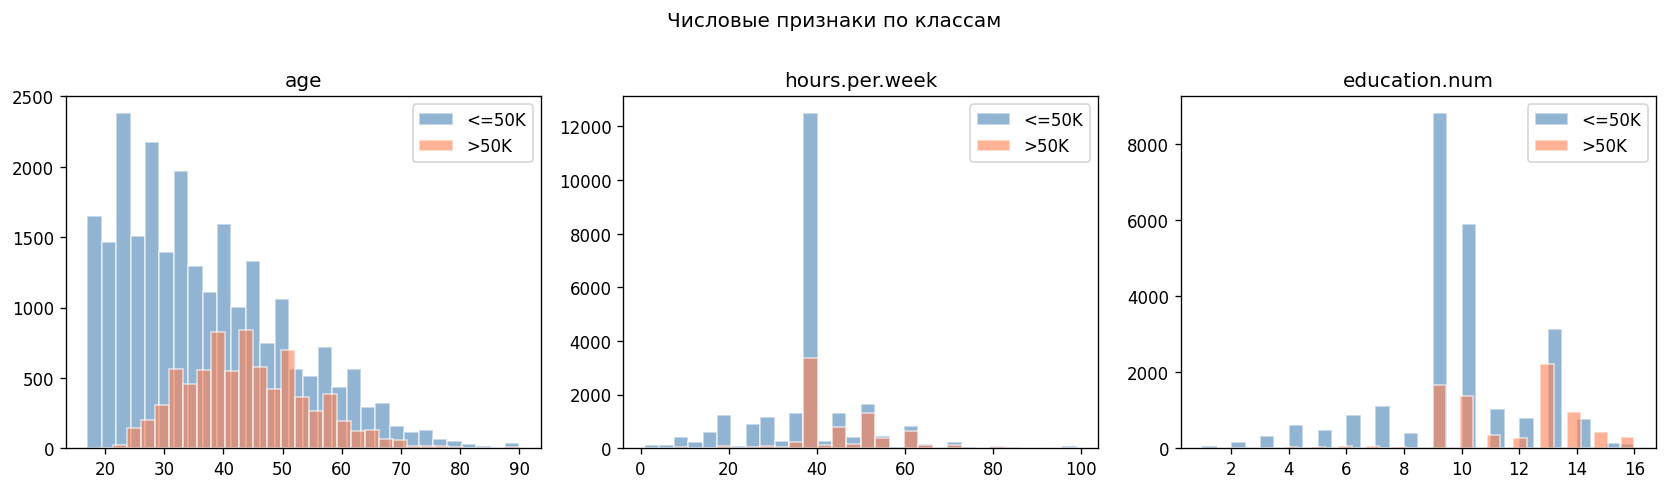

In [57]:
key_num = ["age", "hours.per.week", "education.num"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, key_num):
    for val, label, color in [(0, "<=50K", "steelblue"), (1, ">50K", "coral")]:
        ax.hist(df[df[TARGET] == val][col], bins=30, alpha=0.6, label=label, color=color, edgecolor="white")
    ax.set_title(col)
    ax.legend()
plt.suptitle("Числовые признаки по классам", y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Категориальные признаки vs таргет

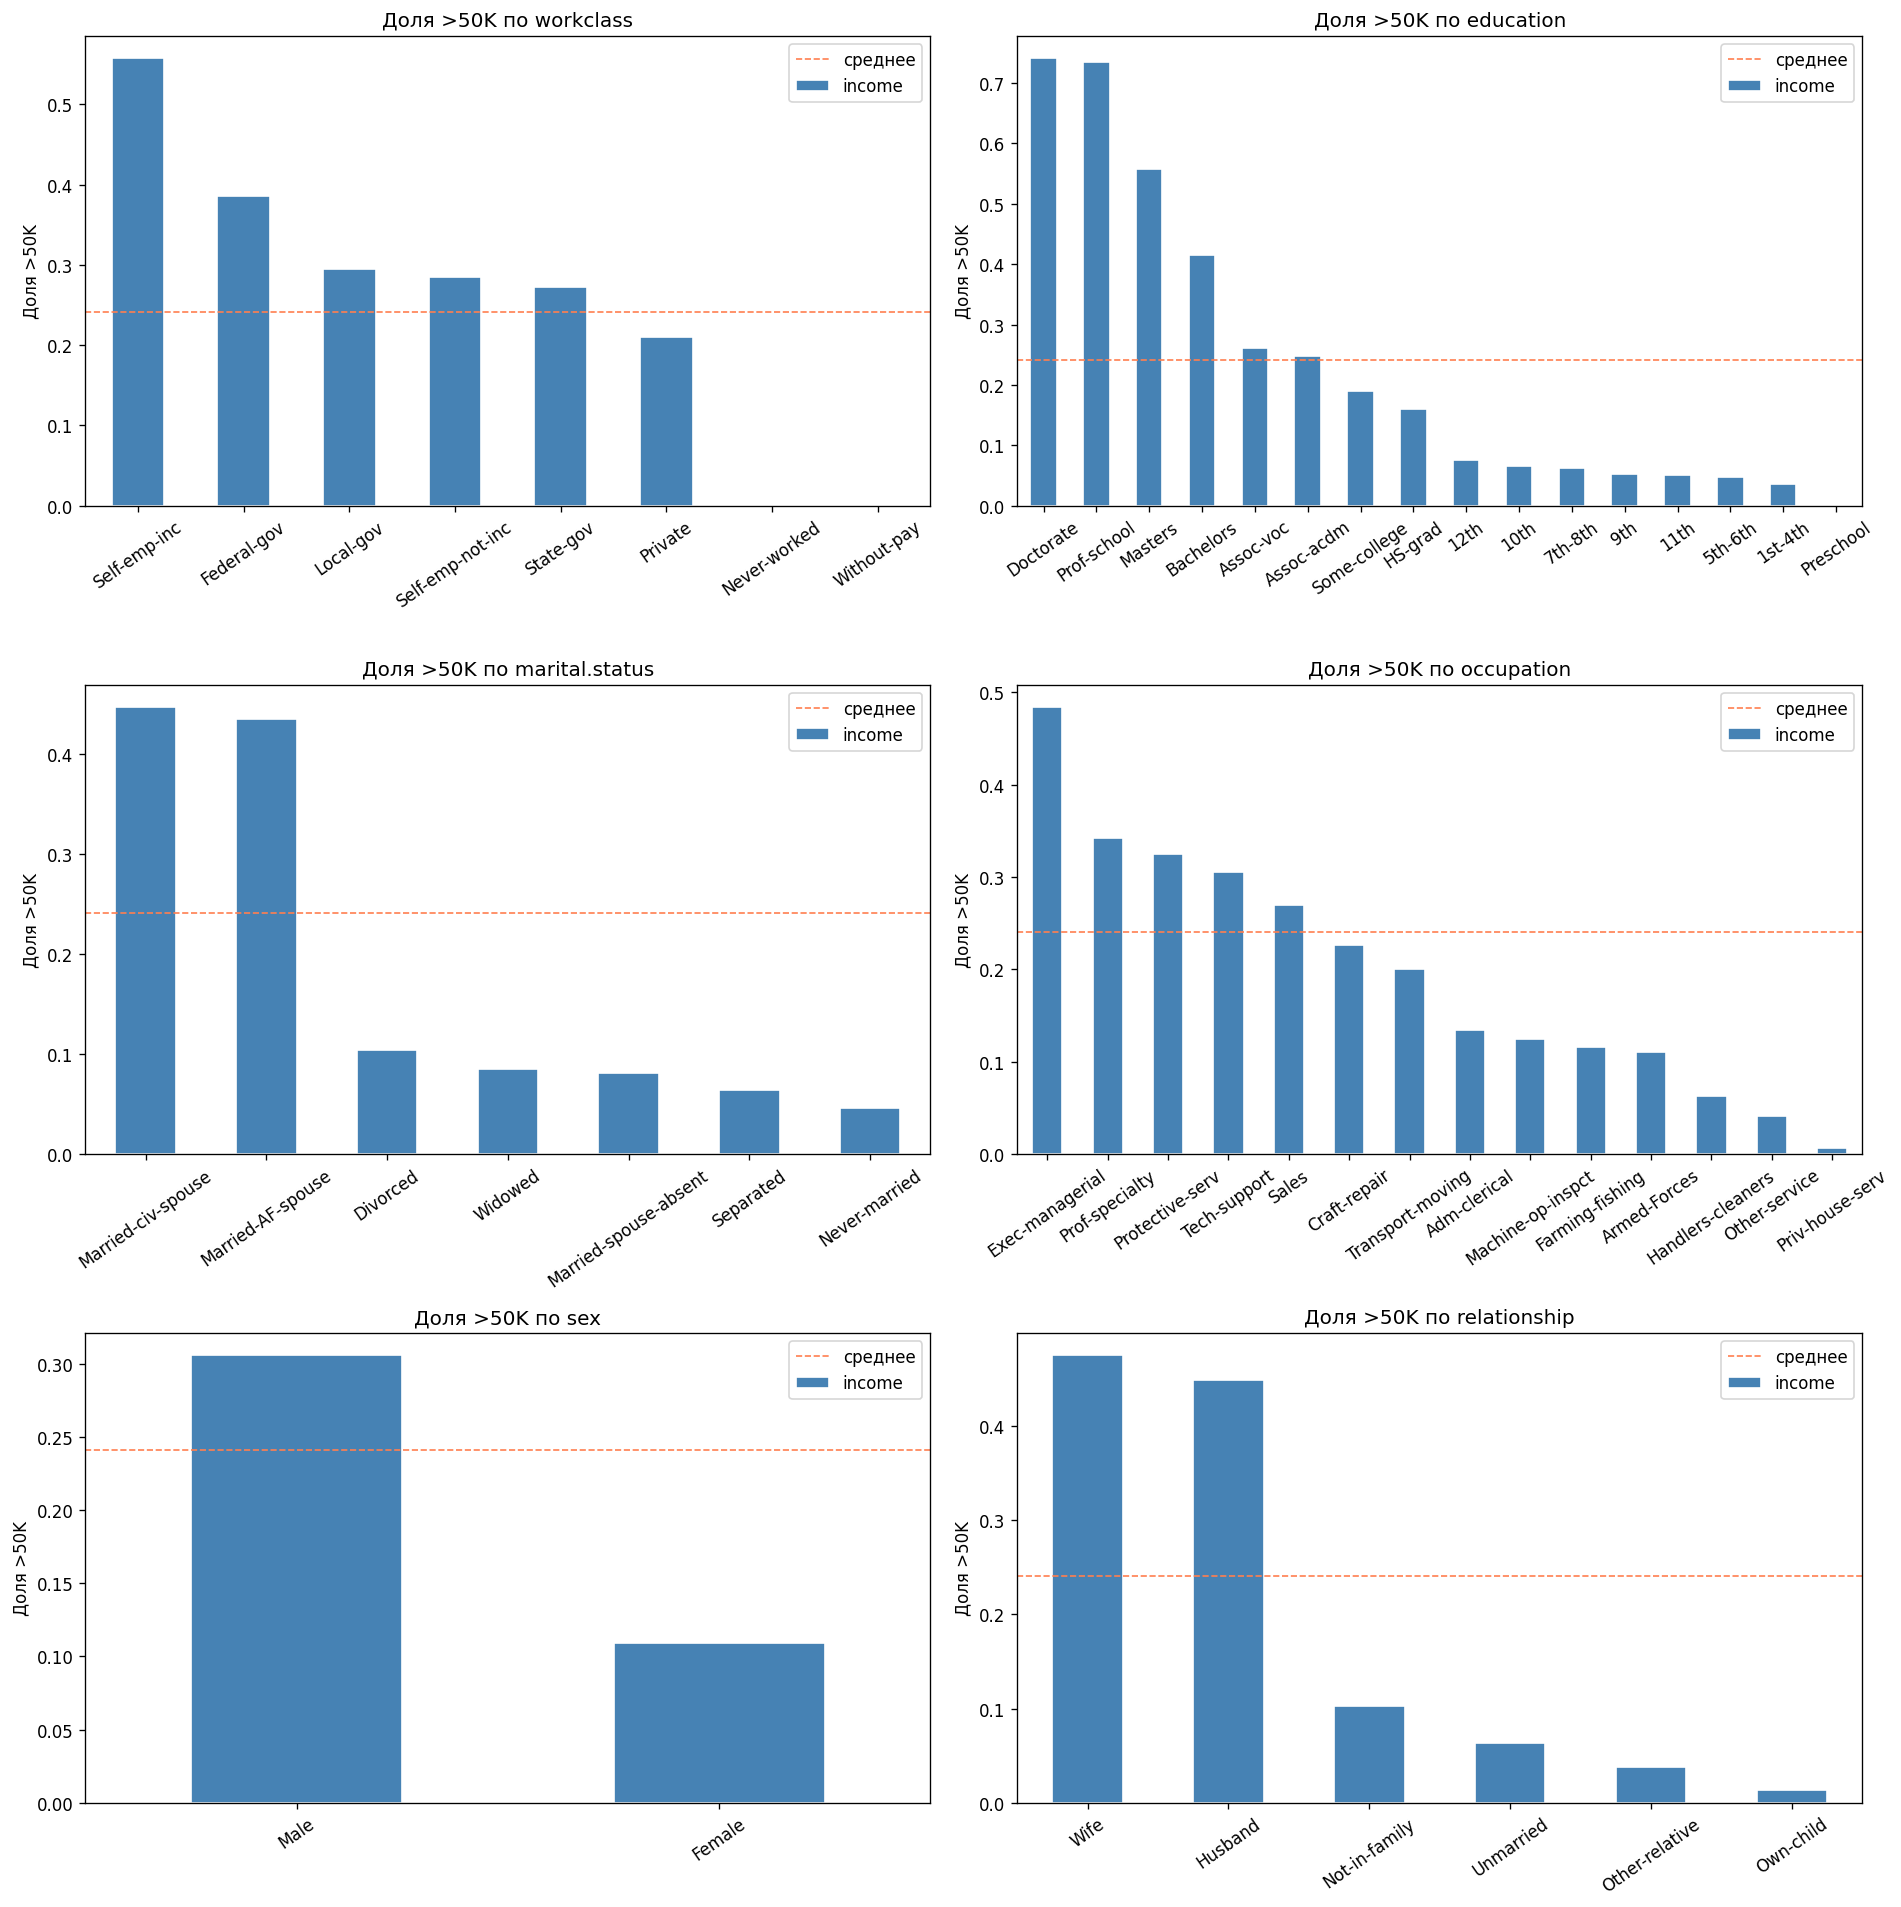

In [58]:
key_cat = ["workclass", "education", "marital.status", "occupation", "sex", "relationship"]

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
for ax, col in zip(axes.flat, key_cat):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Доля >50K по {col}")
    ax.set_ylabel("Доля >50K")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    ax.axhline(df[TARGET].mean(), color="coral", linestyle="--", linewidth=1, label="среднее")
    ax.legend()
plt.tight_layout()
plt.show()

### 3.5 Матрица корреляций числовых признаков

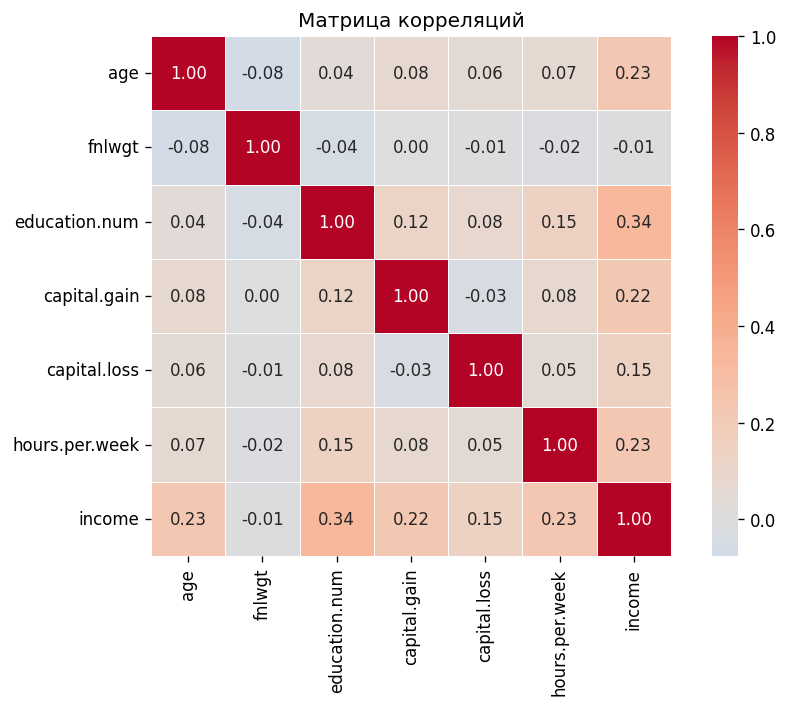

In [59]:
corr = df[NUM_COLS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, ax=ax, linewidths=0.5,
)
ax.set_title("Матрица корреляций")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [60]:
print(f"Признаков до FE: {len(df.columns) - 1}")

# Разница между приростом и потерями капитала
df["capital_net"] = df["capital.gain"] - df["capital.loss"]

# Возрастные группы
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=["<25", "25-35", "35-50", "50-65", "65+"],
).astype("category")

# Бинарный признак: рождён в США
df["is_usa"] = (df["native.country"] == "United-States").astype(int)

print(f"Признаков после FE: {len(df.columns) - 1}")
df[["capital_net", "age_group", "is_usa"]].head()

Признаков до FE: 14
Признаков после FE: 17


,capital_net,age_group,is_usa
0,-4356,65+,1
1,-4356,65+,1
2,-4356,65+,1
3,-3900,50-65,1
4,-3900,35-50,1


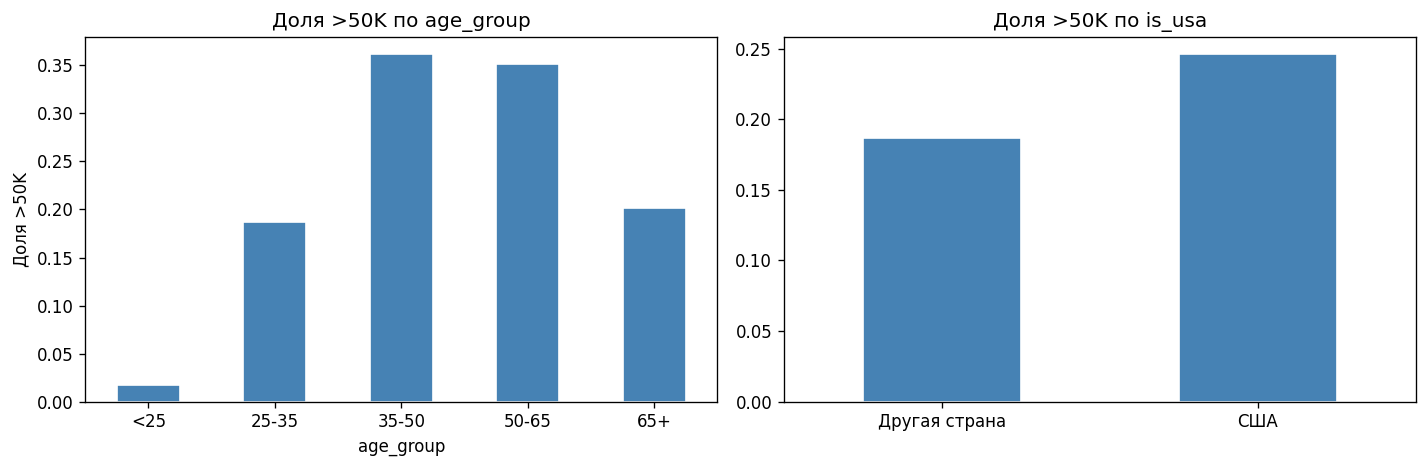

In [61]:
# Как новые признаки связаны с таргетом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rate_age = df.groupby("age_group")[TARGET].mean()
rate_age.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Доля >50K по age_group")
axes[0].set_ylabel("Доля >50K")
axes[0].tick_params(axis="x", rotation=0)

rate_usa = df.groupby("is_usa")[TARGET].mean()
rate_usa.index = ["Другая страна", "США"]
rate_usa.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Доля >50K по is_usa")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 5. Выбор метрики качества

Датасет имеет **дисбаланс классов** (~76% `<=50K`, ~24% `>50K`). При таком соотношении `accuracy` вводит в заблуждение: модель, предсказывающая всегда `<=50K`, получит ~76% accuracy без какой-либо пользы.

**Основная метрика: ROC-AUC**
- Не зависит от порога классификации и дисбаланса классов
- Показывает, насколько хорошо модель ранжирует наблюдения
- Стандарт для задач бинарной классификации с дисбалансом

**Дополнительная метрика: F1-score (macro)**
- Учитывает и Precision, и Recall для обоих классов
- Позволяет контролировать качество именно на миноритарном классе (`>50K`)

`Accuracy` также будем выводить для общей картины, но не использовать как критерий сравнения моделей.

## 6. Сплит данных

In [62]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Разбиение: 70% train, 15% val, 15% test
# stratify=y — сохраняем соотношение классов в каждой выборке
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} ({X_test.shape[0]/len(df)*100:.1f}%)")
print()
print("Доля >50K в каждой выборке:")
print(f"  Train: {y_train.mean():.3f}")
print(f"  Val:   {y_val.mean():.3f}")
print(f"  Test:  {y_test.mean():.3f}")

Train: 22775 (70.0%)
Val:   4881 (15.0%)
Test:  4881 (15.0%)

Доля >50K в каждой выборке:
  Train: 0.241
  Val:   0.241
  Test:  0.241


**Data leakage:** отсутствует. Данные переписи населения — статический срез на один момент времени, записи не связаны между собой. Временной утечки нет. `stratify=y` гарантирует однородное распределение классов, а все трансформации (imputing, encoding, scaling) будут применяться только на `train` и переносятся на `val`/`test` через `Pipeline`.

## 7. Сохранение обработанного датасета

In [63]:
df.to_csv(PROCESSED_PATH, index=False)
print(f"Сохранено: {PROCESSED_PATH}")
print(f"Shape: {df.shape}")

Сохранено: ../data/processed/adult_processed.csv
Shape: (32537, 18)
